# Klebsiella pneumoniae | MIL v5 - Multi-Head Attention + Focal Loss + LayerNorm

Mejoras sobre v4:
1. **Focal Loss** - penaliza errores dificiles, mejora recall clase R
2. **LayerNorm** sobre embeddings NTv3 antes de la atencion
3. **Multi-Head Attention MIL** (4 cabezas) - captura mecanismos paralelos
4. **Dropout mejorado** en embeddings + MIL head
5. **Ablacion Top-k** - experimento para paper (k=1,3,5,10 vs soft-attention)

> Este notebook NO reemplaza el entrenamiento v4; genera modelo independiente en modelo_MIL_v5_best_auc.pth

## Celda 0 - Anti-sueno y Drive

In [ ]:
try:
    from IPython.display import Javascript, display
    display(Javascript('''function ClickConnect(){document.querySelector("colab-toolbar-button#connect")?.click();document.querySelector("colab-dialog.yes-no-dialog paper-button#ok")?.click();}setInterval(ClickConnect,60000);'''))
    print("Anti-sueño activado")
    from google.colab import drive
    drive.mount("../data")
    IN_COLAB = True
    print("✅ Google Colab detectado y Drive montado.")
except Exception:
    IN_COLAB = False
    print("ℹ️ Entorno local detectado (no Google Colab). Omitiendo montaje de Drive.")


<IPython.core.display.Javascript object>

Anti-sueno activado
Mounted at ../data


## Celda 1 - Instalar dependencias

In [ ]:
!pip install -q transformers captum biopython
!pip3 install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu121 --force-reinstall
print("Dependencias listas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 115.9 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/nightly/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.9/767.9 MB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 116.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 107.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 49.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 133.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 21.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56

Dependencias listas


## Celda 2 - Login HuggingFace

In [ ]:
import os
from huggingface_hub import login

# Autenticación con Hugging Face (necesario para descargar modelos)
# Utiliza la variable de entorno HF_TOKEN si está configurada, o solicita login interactivo
hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token)
else:
    login()


## Celda 3 - Configuracion
> Ajusta aqui rutas e hiperparametros.

In [ ]:
import os

# RUTAS BASE
RUTA_BASE    = "../data"
RUTA_FOLDS   = f"{RUTA_BASE}/dataset_limpio"
RUTA_OUTPUTS = f"{RUTA_BASE}/cv_folds"
os.makedirs(RUTA_OUTPUTS, exist_ok=True)

# MODELO
MODEL_NAME   = "InstaDeepAI/NTV3_100M_post"
SPECIES_ID   = 6
MAX_SEQ_LEN  = 512
HIDDEN_DIM   = 128
NUM_HEADS    = 4  # cabezas de atencion multi-head

# FOCAL LOSS
FOCAL_ALPHA  = 0.55
FOCAL_GAMMA  = 2.0

# BOLSAS
MAX_GENES     = 50
SUB_BATCH     = 64
EMBED_DROPOUT = 0.15

KEYWORDS_CARB = ["carbapenem", "beta-lactam", "OXA", "KPC", "NDM", "VIM", "IMP", "GES"]

print("Configuracion CV lista")
print(f"  RUTA_FOLDS   : {RUTA_FOLDS}")
print(f"  RUTA_OUTPUTS : {RUTA_OUTPUTS}")
print(f"  Modelo       : {MODEL_NAME}")
print(f"  Multi-Head   : {NUM_HEADS} cabezas")


Configuracion CV lista
  RUTA_FOLDS   : ../data
  RUTA_OUTPUTS : ../models
  Modelo       : InstaDeepAI/NTV3_100M_post
  Multi-Head   : 4 cabezas


## Celda 4 - Arquitectura NTv3MultiHeadMIL

Mejoras implementadas:
- **LayerNorm** sobre embeddings CLS antes de la atencion (mejora 2)
- **Dropout** sobre embeddings (mejora 4)
- **Multi-Head Attention MIL**: 4 redes de atencion paralelas, cada una puede capturar un mecanismo diferente (carbapenemasas, porinas, efflux, co-resistencias). Sus contextos se concatenan y proyectan a 768d antes de la clasificacion.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.optim import AdamW
from transformers import AutoModel, AutoTokenizer, get_cosine_schedule_with_warmup
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    print(f"  GPU: {props.name} - VRAM: {props.total_memory/1024**3:.1f} GB")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
print("Tokenizador cargado")


class FocalLoss(nn.Module):
    """Focal Loss para clasificacion binaria con logits.
    Penaliza ejemplos facilmente clasificados, enfocando el aprendizaje
    en los casos dificiles de la clase R.
    alpha: peso para clase R. >0.5 incrementa recall R.
    gamma: exponente de modulacion. 0 = CrossEntropy estandar."""
    def __init__(self, alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        alpha_t = torch.where(targets == 1,
                               torch.tensor(self.alpha, device=logits.device),
                               torch.tensor(1 - self.alpha, device=logits.device))
        focal = alpha_t * (1 - pt) ** self.gamma * ce
        return focal.mean()


class NTv3MultiHeadMIL(nn.Module):
    """NTv3 (100M) + Multi-Head Attention MIL para clasificacion a nivel de aislado.

    Flujo:
      1. NTv3 genera embedding CLS [768] por gen.
      2. LayerNorm estabiliza escala (mejora 2).
      3. Dropout sobre embeddings (mejora 4).
      4. NUM_HEADS redes de atencion paralelas (mejora 3).
      5. Contextos concatenados -> proyeccion lineal -> [768] -> clasificador."""

    def __init__(self, model_name, hidden_dim=HIDDEN_DIM,
                 num_heads=NUM_HEADS, embed_dropout=EMBED_DROPOUT):
        super().__init__()
        self.ntv3 = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        self.layer_norm   = nn.LayerNorm(768)
        self.embed_dropout = nn.Dropout(embed_dropout)
        self.attention_heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(768, hidden_dim),
                nn.Tanh(),
                nn.Dropout(0.1),
                nn.Linear(hidden_dim, 1)
            ) for _ in range(num_heads)
        ])
        self.projection = nn.Linear(768 * num_heads, 768)
        self.proj_norm  = nn.LayerNorm(768)
        self.classifier = nn.Linear(768, 2)
        self.dropout    = nn.Dropout(0.1)

    def encode_genes(self, input_ids, attention_mask, species_ids):
        """NTv3 forward + LayerNorm + Dropout sobre embeddings CLS."""
        out = self.ntv3(
            input_ids=input_ids,
            attention_mask=attention_mask,
            species_ids=species_ids,
            output_hidden_states=True
        )
        emb = out.hidden_states[-1][:, 0, :]
        emb = self.layer_norm(emb)      # mejora 2
        emb = self.embed_dropout(emb)   # mejora 4
        return emb

    def classify(self, gene_embeddings):
        """Recibe [N_genes, 768]. Devuelve logits [1,2] y lista de pesos por cabeza."""
        head_contexts, attn_weights_per_head = [], []
        for attn_net in self.attention_heads:
            scores  = attn_net(gene_embeddings)         # [N, 1]
            weights = torch.softmax(scores, dim=0)      # [N, 1]
            context = (weights * gene_embeddings).sum(0)  # [768]
            head_contexts.append(context)
            attn_weights_per_head.append(weights)

        multi_context = torch.cat(head_contexts, dim=0)           # [768*num_heads]
        genome_emb    = self.proj_norm(self.projection(multi_context))  # [768]
        logits        = self.classifier(self.dropout(genome_emb.unsqueeze(0)))
        return logits, attn_weights_per_head


modelo = NTv3MultiHeadMIL(MODEL_NAME).to(device)
n_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"Modelo NTv3MultiHeadMIL instanciado")
print(f"  Parametros entrenables : {n_params/1e6:.1f}M")
print(f"  Cabezas de atencion    : {NUM_HEADS}")

Dispositivo: cuda
  GPU: Tesla T4 - VRAM: 14.6 GB


config.json:   0%|          | 0.00/339k [00:00<?, ?B/s]

configuration_ntv3_posttrained.py:   0%|          | 0.00/4.70k [00:00<?, ?B/s]

configuration_ntv3_pretrained.py:   0%|          | 0.00/8.09k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- configuration_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- configuration_ntv3_posttrained.py
- configuration_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

modeling_ntv3_pretrained.py:   0%|          | 0.00/35.2k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- modeling_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] A new version of the following files was downloaded from https://huggingface.co/InstaDeepAI/ntv3_base_model:
- modeling_ntv3_posttrained.py
- modeling_ntv3_pretrained.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/480M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/370 [00:00<?, ?it/s]

Modelo NTv3MultiHeadMIL instanciado
  Parametros entrenables : 122.8M
  Cabezas de atencion    : 4


## Funciones Auxiliares — Cross-Validation XGBoost

Helpers compartidos por todos los folds:
- `crear_bags`: construye las bolsas MIL desde un DataFrame
- `BagDataset` / DataLoader wrapper
- `encode_bag`: sub-batch forward de NTv3 sobre los genes de una bolsa
- `extraer_embeddings_cv`: extrae el vector `genome_emb` [768] (pre-clasificador) con el modelo **completamente congelado**
- `entrenar_y_evaluar_xgb`: entrena XGBoost y devuelve métricas


In [ ]:
import torch
import numpy as np
import pandas as pd
import xgboost as xgb
import joblib
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns


# ── Construccion de bolsas ────────────────────────────────────────────────
def crear_bags(df, max_genes=MAX_GENES):
    patron = "|".join(KEYWORDS_CARB)
    has_dc = "Drug Class" in df.columns
    bags   = []
    for genome_id, grp in df.groupby("genome_id"):
        label = int(grp["label"].iloc[0])
        seqs  = grp["sequence"].tolist()
        if has_dc and len(seqs) > max_genes:
            es_rel = grp["Drug Class"].str.contains(patron, case=False, na=False)
            rel    = grp[es_rel]["sequence"].tolist()
            otros  = grp[~es_rel]["sequence"].tolist()
            if len(rel) >= max_genes:
                idx  = np.random.choice(len(rel), max_genes, replace=False)
                seqs = [rel[i] for i in idx]
            else:
                cupo = max_genes - len(rel)
                idx  = np.random.choice(len(otros), min(cupo, len(otros)), replace=False)
                seqs = rel + [otros[i] for i in idx]
        elif len(seqs) > max_genes:
            idx  = np.random.choice(len(seqs), max_genes, replace=False)
            seqs = [seqs[i] for i in idx]
        bags.append({"sequences": seqs, "label": label, "genome_id": genome_id})
    return bags


class BagDataset(Dataset):
    def __init__(self, bags, tok, max_len=MAX_SEQ_LEN, species_id=SPECIES_ID):
        self.bags, self.tok = bags, tok
        self.max_len, self.species_id = max_len, species_id

    def __len__(self): return len(self.bags)

    def __getitem__(self, idx):
        bag = self.bags[idx]
        enc = self.tok(
            bag["sequences"], padding="max_length", truncation=True,
            max_length=self.max_len, return_tensors="pt"
        )
        mask = enc.get("attention_mask", torch.ones_like(enc["input_ids"]))
        return {
            "input_ids"     : enc["input_ids"],
            "attention_mask": mask,
            "species_ids"   : torch.tensor(self.species_id, dtype=torch.long),
            "label"         : torch.tensor(bag["label"], dtype=torch.long),
            "genome_id"     : bag["genome_id"],
        }


def encode_bag(model, input_ids, attention_mask, sp_val, sub_batch=SUB_BATCH):
    """Forward de NTv3 en sub-batches → tensor [N_genes, 768]."""
    embs, n = [], input_ids.size(0)
    for s in range(0, n, sub_batch):
        e  = min(s + sub_batch, n)
        sp = torch.full((e - s,), sp_val, dtype=torch.long, device=device)
        embs.append(model.encode_genes(input_ids[s:e], attention_mask[s:e], sp))
    return torch.cat(embs, dim=0)


def extraer_embeddings_cv(model, loader, desc="Extrayendo",
                           return_genome_ids=False, return_mil_score=False):
    """
    Extrae el vector genome_emb [768] (capa previa al clasificador lineal)
    con el modelo en modo evaluacion y parametros completamente congelados.
    Ese vector es la entrada para XGBoost, reemplazando la ultima capa.

    return_genome_ids : tambien devuelve el genome_id de cada bolsa (orden estable).
    return_mil_score  : tambien devuelve la probabilidad MIL-only (clase R),
                         pasando genome_emb por model.classifier (sin XGBoost).
    """
    # Congelar TODAS las capas de la red neuronal
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

    X, y_true, genome_ids, mil_scores = [], [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc=desc):
            ids   = batch["input_ids"].squeeze(0).to(device)
            mask  = batch["attention_mask"].squeeze(0).to(device)
            sp    = batch["species_ids"].item()
            label = batch["label"].item()

            with torch.amp.autocast("cuda"):
                embs = encode_bag(model, ids, mask, sp)

                # ── Replicar classify() hasta genome_emb, SIN pasar por classifier ──
                head_contexts = []
                for attn_net in model.attention_heads:
                    scores  = attn_net(embs)
                    weights = torch.softmax(scores, dim=0)
                    context = (weights * embs).sum(0)
                    head_contexts.append(context)

                multi_context = torch.cat(head_contexts, dim=0)          # [768*num_heads]
                genome_emb    = model.proj_norm(model.projection(multi_context))  # [768]
                # ← Este es el punto de corte: genome_emb entra a XGBoost
                #   en lugar de pasar por model.classifier

                if return_mil_score:
                    # Ablacion MIL-only: genome_emb SI pasa por el classifier original
                    mil_logits = model.classifier(model.dropout(genome_emb.unsqueeze(0)))
                    mil_scores.append(torch.softmax(mil_logits, dim=-1)[0, 1].item())

            X.append(genome_emb.cpu().float().numpy())
            y_true.append(label)
            if return_genome_ids:
                gid = batch["genome_id"]
                gid = gid[0] if isinstance(gid, (list, tuple)) else gid
                genome_ids.append(gid)

    salida = [np.array(X), np.array(y_true)]
    if return_genome_ids:
        salida.append(np.array(genome_ids))
    if return_mil_score:
        salida.append(np.array(mil_scores))
    return tuple(salida) if (return_genome_ids or return_mil_score) else tuple(salida)


def entrenar_y_evaluar_xgb(X_train, y_train, X_val, y_val, fold_idx, ruta_outputs,
                            genome_ids_val=None, mil_score_val=None):
    """Entrena XGBoost, evalúa y guarda modelo + métricas del fold."""
    print(f"\n{'='*55}")
    print(f"ENTRENANDO XGBoost — Fold {fold_idx}")
    print(f"{'='*55}")
    print(f"  X_train : {X_train.shape}  |  X_val : {X_val.shape}")

    clf = xgb.XGBClassifier(
        n_estimators  = 200,
        max_depth     = 4,
        learning_rate = 0.05,
        subsample     = 0.8,
        colsample_bytree = 0.8,
        objective     = "binary:logistic",
        eval_metric   = "auc",
        early_stopping_rounds = 20,
        random_state  = 42,
        device        = "cuda" if torch.cuda.is_available() else "cpu",
    )
    clf.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )

    # Guardar modelo XGBoost del fold
    ruta_xgb = f"{ruta_outputs}/fold{fold_idx}_xgboost.pkl"
    joblib.dump(clf, ruta_xgb)
    print(f"  Modelo XGBoost guardado : {ruta_xgb}")

    # Predicciones
    y_pred  = clf.predict(X_val)
    y_score = clf.predict_proba(X_val)[:, 1]

    auc  = roc_auc_score(y_val, y_score)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred, labels=[0, 1])

    print(f"\n  ROC-AUC  : {auc:.4f}")
    print(f"  F1  S/R  : {f1[0]:.4f} / {f1[1]:.4f}")
    print(f"  Rec S/R  : {rec[0]:.4f} / {rec[1]:.4f}")
    print(classification_report(y_val, y_pred, target_names=["S", "R"]))

    # Matriz de confusion
    cm = confusion_matrix(y_val, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Pred S", "Pred R"],
                yticklabels=["True S", "True R"], ax=ax)
    ax.set_title(f"Confusion Matrix — Fold {fold_idx} (XGBoost)")
    plt.tight_layout()
    plt.savefig(f"{ruta_outputs}/fold{fold_idx}_confusion_matrix_xgb.png", dpi=120)
    plt.show()

    # Guardar predicciones del fold
    np.save(f"{ruta_outputs}/fold{fold_idx}_y_score_xgb.npy", y_score)
    np.save(f"{ruta_outputs}/fold{fold_idx}_y_true.npy",      y_val)
    if genome_ids_val is not None:
        np.save(f"{ruta_outputs}/fold{fold_idx}_genome_id.npy", genome_ids_val)
    if mil_score_val is not None:
        np.save(f"{ruta_outputs}/fold{fold_idx}_y_score_mil.npy", mil_score_val)

    return {"fold": fold_idx, "auc": auc,
            "f1_S": f1[0], "f1_R": f1[1],
            "rec_S": rec[0], "rec_R": rec[1],
            "prec_S": prec[0], "prec_R": prec[1]}


# Acumulador de resultados por fold
resultados_cv = []
print("Funciones auxiliares CV listas.")


Funciones auxiliares CV listas.


## Fold 1 — Cargar Modelo, Congelar Capas, Extraer Embeddings y Entrenar XGBoost

1. Carga `fold1_modelo_best_auc.pth`
2. **Congela** todos los parámetros de la red (NTv3 + LayerNorm + Attention + Projection)
3. La última capa `classifier` queda inutilizada — XGBoost la reemplaza
4. Extrae `genome_emb` [768] para train y val del fold 1
5. Entrena y evalúa XGBoost


Fold 1 | Train : ../data/train_por_cepa_fold1.csv
Fold 1 | Val   : ../data/val_por_cepa_fold1.csv
Fold 1 | Modelo: ../models/fold1_modelo_best_auc.pth
  Train: 16,000 seqs | 3093 cepas
  Val  : 3,300 seqs | 609 cepas
  Bolsas train: 3093 | val: 609

Cargando checkpoint: ../models/fold1_modelo_best_auc.pth
  Checkpoint cargado — Época 8 — AUC 0.8725
  Parametros congelados : 122.8M
  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost

Extrayendo embeddings de validacion...


Fold 1 — Val:   0%|          | 0/609 [00:00<?, ?it/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Extrayendo embeddings de entrenamiento...


Fold 1 — Train:   0%|          | 0/3093 [00:00<?, ?it/s]

Embeddings fold 1 OK — train (3093, 768) | val (609, 768)

ENTRENANDO XGBoost — Fold 1
  X_train : (3093, 768)  |  X_val : (609, 768)
  Modelo XGBoost guardado : ../models/fold1_xgboost.pkl

  ROC-AUC  : 0.8684
  F1  S/R  : 0.8485 / 0.7183
  Rec S/R  : 0.8773 / 0.6770
              precision    recall  f1-score   support

           S       0.82      0.88      0.85       383
           R       0.77      0.68      0.72       226

    accuracy                           0.80       609
   macro avg       0.79      0.78      0.78       609
weighted avg       0.80      0.80      0.80       609



/usr/local/lib/python3.12/dist-packages/xgboost/core.py:553: UserWarning: [13:18:27] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


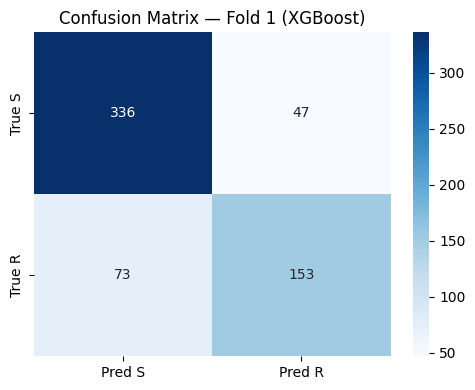


Fold 1 completado.


In [ ]:
# ════════════════════════════════════════════════════
# FOLD 1
# ════════════════════════════════════════════════════
fold_idx = 1

# ── 1. Rutas de datos y modelo del fold ─────────────
ruta_train  = f"{RUTA_FOLDS}/train_por_cepa_fold{fold_idx}.csv"
ruta_val    = f"{RUTA_FOLDS}/val_por_cepa_fold{fold_idx}.csv"
ruta_modelo = f"{RUTA_OUTPUTS}/fold{fold_idx}_modelo_best_auc.pth"

print(f"Fold {fold_idx} | Train : {ruta_train}")
print(f"Fold {fold_idx} | Val   : {ruta_val}")
print(f"Fold {fold_idx} | Modelo: {ruta_modelo}")

# ── 2. Cargar datos del fold ─────────────────────────
train_df_f1 = pd.read_csv(ruta_train)
val_df_f1   = pd.read_csv(ruta_val)
print(f"  Train: {len(train_df_f1):,} seqs | "
      f"{train_df_f1['genome_id'].nunique()} cepas")
print(f"  Val  : {len(val_df_f1):,} seqs | "
      f"{val_df_f1['genome_id'].nunique()} cepas")

# ── 3. Construir bolsas y DataLoaders ────────────────
train_bags_f1 = crear_bags(train_df_f1)
val_bags_f1   = crear_bags(val_df_f1)
print(f"  Bolsas train: {len(train_bags_f1)} | "
      f"val: {len(val_bags_f1)}")

train_loader_f1 = DataLoader(
    BagDataset(train_bags_f1, tokenizer),
    batch_size=1, shuffle=True
)
val_loader_f1 = DataLoader(
    BagDataset(val_bags_f1, tokenizer),
    batch_size=1, shuffle=False
)

# ── 4. Cargar pesos del fold en el modelo ─────────────
print(f"\nCargando checkpoint: {ruta_modelo}")
ckpt_f1 = torch.load(ruta_modelo, map_location=device, weights_only=False)
modelo.load_state_dict(ckpt_f1["model_state_dict"], strict=False)
print(f"  Checkpoint cargado — Época {ckpt_f1['epoch']} "
      f"— AUC {ckpt_f1['auc']:.4f}")

# ── 5. Congelar TODA la red neuronal ──────────────────
# La ultima capa (modelo.classifier) queda inutilizada;
# XGBoost reemplaza esa ultima capa lineal.
modelo.eval()
for param in modelo.parameters():
    param.requires_grad = False
n_frozen = sum(p.numel() for p in modelo.parameters())
print(f"  Parametros congelados : {n_frozen/1e6:.1f}M")
print(f"  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost")

# ── 6. Extraer embeddings genome_emb [768] ────────────
print("\nExtrayendo embeddings de validacion...")
X_val_f1, y_val_f1, genome_ids_val_f1, mil_score_val_f1 = extraer_embeddings_cv(
    modelo, val_loader_f1,
    desc=f"Fold 1 — Val",
    return_genome_ids=True,
    return_mil_score=True
)

print("Extrayendo embeddings de entrenamiento...")
X_train_f1, y_train_f1 = extraer_embeddings_cv(
    modelo, train_loader_f1,
    desc=f"Fold 1 — Train"
)

print(f"Embeddings fold {fold_idx} OK "
      f"— train {X_train_f1.shape} | val {X_val_f1.shape}")

# ── 7. Entrenar XGBoost (reemplaza la ultima capa) ────
res_f1 = entrenar_y_evaluar_xgb(
    X_train_f1, y_train_f1,
    X_val_f1,   y_val_f1,
    fold_idx=fold_idx,
    ruta_outputs=RUTA_OUTPUTS,
    genome_ids_val=genome_ids_val_f1,
    mil_score_val=mil_score_val_f1
)
resultados_cv.append(res_f1)

# Liberar memoria GPU del fold antes del siguiente
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"\nFold 1 completado.")


## Fold 2 — Cargar Modelo, Congelar Capas, Extraer Embeddings y Entrenar XGBoost

1. Carga `fold2_modelo_best_auc.pth`
2. **Congela** todos los parámetros de la red (NTv3 + LayerNorm + Attention + Projection)
3. La última capa `classifier` queda inutilizada — XGBoost la reemplaza
4. Extrae `genome_emb` [768] para train y val del fold 2
5. Entrena y evalúa XGBoost


Fold 2 | Train : ../data/train_por_cepa_fold2.csv
Fold 2 | Val   : ../data/val_por_cepa_fold2.csv
Fold 2 | Modelo: ../models/fold2_modelo_best_auc.pth
  Train: 16,704 seqs | 3161 cepas
  Val  : 2,596 seqs | 541 cepas
  Bolsas train: 3161 | val: 541

Cargando checkpoint: ../models/fold2_modelo_best_auc.pth
  Checkpoint cargado — Época 3 — AUC 0.7273
  Parametros congelados : 122.8M
  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost

Extrayendo embeddings de validacion...


Fold 2 — Val:   0%|          | 0/541 [00:00<?, ?it/s]

Extrayendo embeddings de entrenamiento...


Fold 2 — Train:   0%|          | 0/3161 [00:00<?, ?it/s]

Embeddings fold 2 OK — train (3161, 768) | val (541, 768)

ENTRENANDO XGBoost — Fold 2
  X_train : (3161, 768)  |  X_val : (541, 768)
  Modelo XGBoost guardado : ../models/fold2_xgboost.pkl

  ROC-AUC  : 0.7869
  F1  S/R  : 0.8328 / 0.0000
  Rec S/R  : 1.0000 / 0.0000
              precision    recall  f1-score   support

           S       0.71      1.00      0.83       386
           R       0.00      0.00      0.00       155

    accuracy                           0.71       541
   macro avg       0.36      0.50      0.42       541
weighted avg       0.51      0.71      0.59       541



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

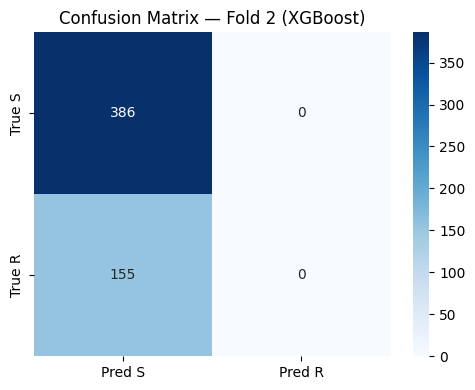


Fold 2 completado.


In [ ]:
# ════════════════════════════════════════════════════
# FOLD 2
# ════════════════════════════════════════════════════
fold_idx = 2

# ── 1. Rutas de datos y modelo del fold ─────────────
ruta_train  = f"{RUTA_FOLDS}/train_por_cepa_fold{fold_idx}.csv"
ruta_val    = f"{RUTA_FOLDS}/val_por_cepa_fold{fold_idx}.csv"
ruta_modelo = f"{RUTA_OUTPUTS}/fold{fold_idx}_modelo_best_auc.pth"

print(f"Fold {fold_idx} | Train : {ruta_train}")
print(f"Fold {fold_idx} | Val   : {ruta_val}")
print(f"Fold {fold_idx} | Modelo: {ruta_modelo}")

# ── 2. Cargar datos del fold ─────────────────────────
train_df_f2 = pd.read_csv(ruta_train)
val_df_f2   = pd.read_csv(ruta_val)
print(f"  Train: {len(train_df_f2):,} seqs | "
      f"{train_df_f2['genome_id'].nunique()} cepas")
print(f"  Val  : {len(val_df_f2):,} seqs | "
      f"{val_df_f2['genome_id'].nunique()} cepas")

# ── 3. Construir bolsas y DataLoaders ────────────────
train_bags_f2 = crear_bags(train_df_f2)
val_bags_f2   = crear_bags(val_df_f2)
print(f"  Bolsas train: {len(train_bags_f2)} | "
      f"val: {len(val_bags_f2)}")

train_loader_f2 = DataLoader(
    BagDataset(train_bags_f2, tokenizer),
    batch_size=1, shuffle=True
)
val_loader_f2 = DataLoader(
    BagDataset(val_bags_f2, tokenizer),
    batch_size=1, shuffle=False
)

# ── 4. Cargar pesos del fold en el modelo ─────────────
print(f"\nCargando checkpoint: {ruta_modelo}")
ckpt_f2 = torch.load(ruta_modelo, map_location=device, weights_only=False)
modelo.load_state_dict(ckpt_f2["model_state_dict"], strict=False)
print(f"  Checkpoint cargado — Época {ckpt_f2['epoch']} "
      f"— AUC {ckpt_f2['auc']:.4f}")

# ── 5. Congelar TODA la red neuronal ──────────────────
# La ultima capa (modelo.classifier) queda inutilizada;
# XGBoost reemplaza esa ultima capa lineal.
modelo.eval()
for param in modelo.parameters():
    param.requires_grad = False
n_frozen = sum(p.numel() for p in modelo.parameters())
print(f"  Parametros congelados : {n_frozen/1e6:.1f}M")
print(f"  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost")

# ── 6. Extraer embeddings genome_emb [768] ────────────
print("\nExtrayendo embeddings de validacion...")
X_val_f2, y_val_f2, genome_ids_val_f2, mil_score_val_f2 = extraer_embeddings_cv(
    modelo, val_loader_f2,
    desc=f"Fold 2 — Val",
    return_genome_ids=True,
    return_mil_score=True
)

print("Extrayendo embeddings de entrenamiento...")
X_train_f2, y_train_f2 = extraer_embeddings_cv(
    modelo, train_loader_f2,
    desc=f"Fold 2 — Train"
)

print(f"Embeddings fold {fold_idx} OK "
      f"— train {X_train_f2.shape} | val {X_val_f2.shape}")

# ── 7. Entrenar XGBoost (reemplaza la ultima capa) ────
res_f2 = entrenar_y_evaluar_xgb(
    X_train_f2, y_train_f2,
    X_val_f2,   y_val_f2,
    fold_idx=fold_idx,
    ruta_outputs=RUTA_OUTPUTS,
    genome_ids_val=genome_ids_val_f2,
    mil_score_val=mil_score_val_f2
)
resultados_cv.append(res_f2)

# Liberar memoria GPU del fold antes del siguiente
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"\nFold 2 completado.")


## Fold 3 — Cargar Modelo, Congelar Capas, Extraer Embeddings y Entrenar XGBoost

1. Carga `fold3_modelo_best_auc.pth`
2. **Congela** todos los parámetros de la red (NTv3 + LayerNorm + Attention + Projection)
3. La última capa `classifier` queda inutilizada — XGBoost la reemplaza
4. Extrae `genome_emb` [768] para train y val del fold 3
5. Entrena y evalúa XGBoost


Fold 3 | Train : ../data/train_por_cepa_fold3.csv
Fold 3 | Val   : ../data/val_por_cepa_fold3.csv
Fold 3 | Modelo: ../models/fold3_modelo_best_auc.pth
  Train: 16,693 seqs | 3276 cepas
  Val  : 2,607 seqs | 426 cepas
  Bolsas train: 3276 | val: 426

Cargando checkpoint: ../models/fold3_modelo_best_auc.pth
  Checkpoint cargado — Época 3 — AUC 0.7990
  Parametros congelados : 122.8M
  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost

Extrayendo embeddings de validacion...


Fold 3 — Val:   0%|          | 0/426 [00:00<?, ?it/s]

Extrayendo embeddings de entrenamiento...


Fold 3 — Train:   0%|          | 0/3276 [00:00<?, ?it/s]

Embeddings fold 3 OK — train (3276, 768) | val (426, 768)

ENTRENANDO XGBoost — Fold 3
  X_train : (3276, 768)  |  X_val : (426, 768)
  Modelo XGBoost guardado : ../models/fold3_xgboost.pkl

  ROC-AUC  : 0.7742
  F1  S/R  : 0.8333 / 0.5439
  Rec S/R  : 0.8638 / 0.4960
              precision    recall  f1-score   support

           S       0.80      0.86      0.83       301
           R       0.60      0.50      0.54       125

    accuracy                           0.76       426
   macro avg       0.70      0.68      0.69       426
weighted avg       0.75      0.76      0.75       426



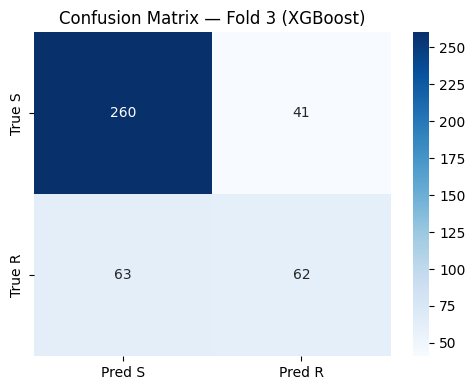


Fold 3 completado.


In [ ]:
# ════════════════════════════════════════════════════
# FOLD 3
# ════════════════════════════════════════════════════
fold_idx = 3

# ── 1. Rutas de datos y modelo del fold ─────────────
ruta_train  = f"{RUTA_FOLDS}/train_por_cepa_fold{fold_idx}.csv"
ruta_val    = f"{RUTA_FOLDS}/val_por_cepa_fold{fold_idx}.csv"
ruta_modelo = f"{RUTA_OUTPUTS}/fold{fold_idx}_modelo_best_auc.pth"

print(f"Fold {fold_idx} | Train : {ruta_train}")
print(f"Fold {fold_idx} | Val   : {ruta_val}")
print(f"Fold {fold_idx} | Modelo: {ruta_modelo}")

# ── 2. Cargar datos del fold ─────────────────────────
train_df_f3 = pd.read_csv(ruta_train)
val_df_f3   = pd.read_csv(ruta_val)
print(f"  Train: {len(train_df_f3):,} seqs | "
      f"{train_df_f3['genome_id'].nunique()} cepas")
print(f"  Val  : {len(val_df_f3):,} seqs | "
      f"{val_df_f3['genome_id'].nunique()} cepas")

# ── 3. Construir bolsas y DataLoaders ────────────────
train_bags_f3 = crear_bags(train_df_f3)
val_bags_f3   = crear_bags(val_df_f3)
print(f"  Bolsas train: {len(train_bags_f3)} | "
      f"val: {len(val_bags_f3)}")

train_loader_f3 = DataLoader(
    BagDataset(train_bags_f3, tokenizer),
    batch_size=1, shuffle=True
)
val_loader_f3 = DataLoader(
    BagDataset(val_bags_f3, tokenizer),
    batch_size=1, shuffle=False
)

# ── 4. Cargar pesos del fold en el modelo ─────────────
print(f"\nCargando checkpoint: {ruta_modelo}")
ckpt_f3 = torch.load(ruta_modelo, map_location=device, weights_only=False)
modelo.load_state_dict(ckpt_f3["model_state_dict"], strict=False)
print(f"  Checkpoint cargado — Época {ckpt_f3['epoch']} "
      f"— AUC {ckpt_f3['auc']:.4f}")

# ── 5. Congelar TODA la red neuronal ──────────────────
# La ultima capa (modelo.classifier) queda inutilizada;
# XGBoost reemplaza esa ultima capa lineal.
modelo.eval()
for param in modelo.parameters():
    param.requires_grad = False
n_frozen = sum(p.numel() for p in modelo.parameters())
print(f"  Parametros congelados : {n_frozen/1e6:.1f}M")
print(f"  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost")

# ── 6. Extraer embeddings genome_emb [768] ────────────
print("\nExtrayendo embeddings de validacion...")
X_val_f3, y_val_f3, genome_ids_val_f3, mil_score_val_f3 = extraer_embeddings_cv(
    modelo, val_loader_f3,
    desc=f"Fold 3 — Val",
    return_genome_ids=True,
    return_mil_score=True
)

print("Extrayendo embeddings de entrenamiento...")
X_train_f3, y_train_f3 = extraer_embeddings_cv(
    modelo, train_loader_f3,
    desc=f"Fold 3 — Train"
)

print(f"Embeddings fold {fold_idx} OK "
      f"— train {X_train_f3.shape} | val {X_val_f3.shape}")

# ── 7. Entrenar XGBoost (reemplaza la ultima capa) ────
res_f3 = entrenar_y_evaluar_xgb(
    X_train_f3, y_train_f3,
    X_val_f3,   y_val_f3,
    fold_idx=fold_idx,
    ruta_outputs=RUTA_OUTPUTS,
    genome_ids_val=genome_ids_val_f3,
    mil_score_val=mil_score_val_f3
)
resultados_cv.append(res_f3)

# Liberar memoria GPU del fold antes del siguiente
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"\nFold 3 completado.")


## Fold 4 — Cargar Modelo, Congelar Capas, Extraer Embeddings y Entrenar XGBoost

1. Carga `fold4_modelo_best_auc.pth`
2. **Congela** todos los parámetros de la red (NTv3 + LayerNorm + Attention + Projection)
3. La última capa `classifier` queda inutilizada — XGBoost la reemplaza
4. Extrae `genome_emb` [768] para train y val del fold 4
5. Entrena y evalúa XGBoost


Fold 4 | Train : ../data/train_por_cepa_fold4.csv
Fold 4 | Val   : ../data/val_por_cepa_fold4.csv
Fold 4 | Modelo: ../models/fold4_modelo_best_auc.pth
  Train: 11,192 seqs | 2295 cepas
  Val  : 8,108 seqs | 1407 cepas
  Bolsas train: 2295 | val: 1407

Cargando checkpoint: ../models/fold4_modelo_best_auc.pth
  Checkpoint cargado — Época 9 — AUC 0.8501
  Parametros congelados : 122.8M
  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost

Extrayendo embeddings de validacion...


Fold 4 — Val:   0%|          | 0/1407 [00:00<?, ?it/s]

Extrayendo embeddings de entrenamiento...


Fold 4 — Train:   0%|          | 0/2295 [00:00<?, ?it/s]

Embeddings fold 4 OK — train (2295, 768) | val (1407, 768)

ENTRENANDO XGBoost — Fold 4
  X_train : (2295, 768)  |  X_val : (1407, 768)
  Modelo XGBoost guardado : ../models/fold4_xgboost.pkl

  ROC-AUC  : 0.8548
  F1  S/R  : 0.7915 / 0.6592
  Rec S/R  : 0.8951 / 0.5543
              precision    recall  f1-score   support

           S       0.71      0.90      0.79       772
           R       0.81      0.55      0.66       635

    accuracy                           0.74      1407
   macro avg       0.76      0.72      0.73      1407
weighted avg       0.76      0.74      0.73      1407



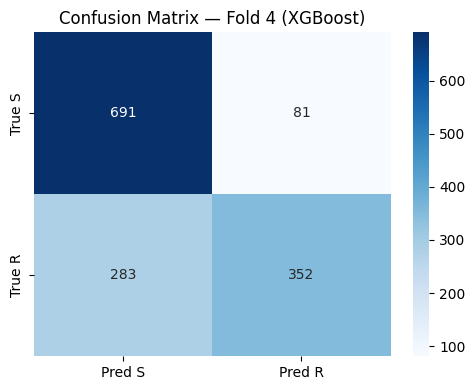


Fold 4 completado.


In [ ]:
# ════════════════════════════════════════════════════
# FOLD 4
# ════════════════════════════════════════════════════
fold_idx = 4

# ── 1. Rutas de datos y modelo del fold ─────────────
ruta_train  = f"{RUTA_FOLDS}/train_por_cepa_fold{fold_idx}.csv"
ruta_val    = f"{RUTA_FOLDS}/val_por_cepa_fold{fold_idx}.csv"
ruta_modelo = f"{RUTA_OUTPUTS}/fold{fold_idx}_modelo_best_auc.pth"

print(f"Fold {fold_idx} | Train : {ruta_train}")
print(f"Fold {fold_idx} | Val   : {ruta_val}")
print(f"Fold {fold_idx} | Modelo: {ruta_modelo}")

# ── 2. Cargar datos del fold ─────────────────────────
train_df_f4 = pd.read_csv(ruta_train)
val_df_f4   = pd.read_csv(ruta_val)
print(f"  Train: {len(train_df_f4):,} seqs | "
      f"{train_df_f4['genome_id'].nunique()} cepas")
print(f"  Val  : {len(val_df_f4):,} seqs | "
      f"{val_df_f4['genome_id'].nunique()} cepas")

# ── 3. Construir bolsas y DataLoaders ────────────────
train_bags_f4 = crear_bags(train_df_f4)
val_bags_f4   = crear_bags(val_df_f4)
print(f"  Bolsas train: {len(train_bags_f4)} | "
      f"val: {len(val_bags_f4)}")

train_loader_f4 = DataLoader(
    BagDataset(train_bags_f4, tokenizer),
    batch_size=1, shuffle=True
)
val_loader_f4 = DataLoader(
    BagDataset(val_bags_f4, tokenizer),
    batch_size=1, shuffle=False
)

# ── 4. Cargar pesos del fold en el modelo ─────────────
print(f"\nCargando checkpoint: {ruta_modelo}")
ckpt_f4 = torch.load(ruta_modelo, map_location=device, weights_only=False)
modelo.load_state_dict(ckpt_f4["model_state_dict"], strict=False)
print(f"  Checkpoint cargado — Época {ckpt_f4['epoch']} "
      f"— AUC {ckpt_f4['auc']:.4f}")

# ── 5. Congelar TODA la red neuronal ──────────────────
# La ultima capa (modelo.classifier) queda inutilizada;
# XGBoost reemplaza esa ultima capa lineal.
modelo.eval()
for param in modelo.parameters():
    param.requires_grad = False
n_frozen = sum(p.numel() for p in modelo.parameters())
print(f"  Parametros congelados : {n_frozen/1e6:.1f}M")
print(f"  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost")

# ── 6. Extraer embeddings genome_emb [768] ────────────
print("\nExtrayendo embeddings de validacion...")
X_val_f4, y_val_f4, genome_ids_val_f4, mil_score_val_f4 = extraer_embeddings_cv(
    modelo, val_loader_f4,
    desc=f"Fold 4 — Val",
    return_genome_ids=True,
    return_mil_score=True
)

print("Extrayendo embeddings de entrenamiento...")
X_train_f4, y_train_f4 = extraer_embeddings_cv(
    modelo, train_loader_f4,
    desc=f"Fold 4 — Train"
)

print(f"Embeddings fold {fold_idx} OK "
      f"— train {X_train_f4.shape} | val {X_val_f4.shape}")

# ── 7. Entrenar XGBoost (reemplaza la ultima capa) ────
res_f4 = entrenar_y_evaluar_xgb(
    X_train_f4, y_train_f4,
    X_val_f4,   y_val_f4,
    fold_idx=fold_idx,
    ruta_outputs=RUTA_OUTPUTS,
    genome_ids_val=genome_ids_val_f4,
    mil_score_val=mil_score_val_f4
)
resultados_cv.append(res_f4)

# Liberar memoria GPU del fold antes del siguiente
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"\nFold 4 completado.")


## Fold 5 — Cargar Modelo, Congelar Capas, Extraer Embeddings y Entrenar XGBoost

1. Carga `fold5_modelo_best_auc.pth`
2. **Congela** todos los parámetros de la red (NTv3 + LayerNorm + Attention + Projection)
3. La última capa `classifier` queda inutilizada — XGBoost la reemplaza
4. Extrae `genome_emb` [768] para train y val del fold 5
5. Entrena y evalúa XGBoost


Fold 5 | Train : ../data/train_por_cepa_fold5.csv
Fold 5 | Val   : ../data/val_por_cepa_fold5.csv
Fold 5 | Modelo: ../models/fold5_modelo_best_auc.pth
  Train: 16,611 seqs | 2983 cepas
  Val  : 2,689 seqs | 719 cepas
  Bolsas train: 2983 | val: 719

Cargando checkpoint: ../models/fold5_modelo_best_auc.pth
  Checkpoint cargado — Época 4 — AUC 0.7640
  Parametros congelados : 122.8M
  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost

Extrayendo embeddings de validacion...


Fold 5 — Val:   0%|          | 0/719 [00:00<?, ?it/s]

Extrayendo embeddings de entrenamiento...


Fold 5 — Train:   0%|          | 0/2983 [00:00<?, ?it/s]

Embeddings fold 5 OK — train (2983, 768) | val (719, 768)

ENTRENANDO XGBoost — Fold 5
  X_train : (2983, 768)  |  X_val : (719, 768)
  Modelo XGBoost guardado : ../models/fold5_xgboost.pkl

  ROC-AUC  : 0.7453
  F1  S/R  : 0.7286 / 0.0000
  Rec S/R  : 1.0000 / 0.0000
              precision    recall  f1-score   support

           S       0.57      1.00      0.73       412
           R       0.00      0.00      0.00       307

    accuracy                           0.57       719
   macro avg       0.29      0.50      0.36       719
weighted avg       0.33      0.57      0.42       719



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

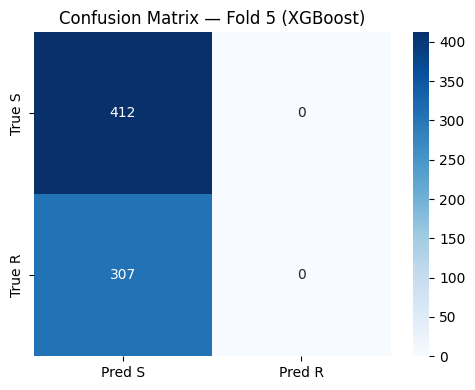


Fold 5 completado.


In [ ]:
# ════════════════════════════════════════════════════
# FOLD 5
# ════════════════════════════════════════════════════
fold_idx = 5

# ── 1. Rutas de datos y modelo del fold ─────────────
ruta_train  = f"{RUTA_FOLDS}/train_por_cepa_fold{fold_idx}.csv"
ruta_val    = f"{RUTA_FOLDS}/val_por_cepa_fold{fold_idx}.csv"
ruta_modelo = f"{RUTA_OUTPUTS}/fold{fold_idx}_modelo_best_auc.pth"

print(f"Fold {fold_idx} | Train : {ruta_train}")
print(f"Fold {fold_idx} | Val   : {ruta_val}")
print(f"Fold {fold_idx} | Modelo: {ruta_modelo}")

# ── 2. Cargar datos del fold ─────────────────────────
train_df_f5 = pd.read_csv(ruta_train)
val_df_f5   = pd.read_csv(ruta_val)
print(f"  Train: {len(train_df_f5):,} seqs | "
      f"{train_df_f5['genome_id'].nunique()} cepas")
print(f"  Val  : {len(val_df_f5):,} seqs | "
      f"{val_df_f5['genome_id'].nunique()} cepas")

# ── 3. Construir bolsas y DataLoaders ────────────────
train_bags_f5 = crear_bags(train_df_f5)
val_bags_f5   = crear_bags(val_df_f5)
print(f"  Bolsas train: {len(train_bags_f5)} | "
      f"val: {len(val_bags_f5)}")

train_loader_f5 = DataLoader(
    BagDataset(train_bags_f5, tokenizer),
    batch_size=1, shuffle=True
)
val_loader_f5 = DataLoader(
    BagDataset(val_bags_f5, tokenizer),
    batch_size=1, shuffle=False
)

# ── 4. Cargar pesos del fold en el modelo ─────────────
print(f"\nCargando checkpoint: {ruta_modelo}")
ckpt_f5 = torch.load(ruta_modelo, map_location=device, weights_only=False)
modelo.load_state_dict(ckpt_f5["model_state_dict"], strict=False)
print(f"  Checkpoint cargado — Época {ckpt_f5['epoch']} "
      f"— AUC {ckpt_f5['auc']:.4f}")

# ── 5. Congelar TODA la red neuronal ──────────────────
# La ultima capa (modelo.classifier) queda inutilizada;
# XGBoost reemplaza esa ultima capa lineal.
modelo.eval()
for param in modelo.parameters():
    param.requires_grad = False
n_frozen = sum(p.numel() for p in modelo.parameters())
print(f"  Parametros congelados : {n_frozen/1e6:.1f}M")
print(f"  Capa 'classifier' (ultima) : congelada y reemplazada por XGBoost")

# ── 6. Extraer embeddings genome_emb [768] ────────────
print("\nExtrayendo embeddings de validacion...")
X_val_f5, y_val_f5, genome_ids_val_f5, mil_score_val_f5 = extraer_embeddings_cv(
    modelo, val_loader_f5,
    desc=f"Fold 5 — Val",
    return_genome_ids=True,
    return_mil_score=True
)

print("Extrayendo embeddings de entrenamiento...")
X_train_f5, y_train_f5 = extraer_embeddings_cv(
    modelo, train_loader_f5,
    desc=f"Fold 5 — Train"
)

print(f"Embeddings fold {fold_idx} OK "
      f"— train {X_train_f5.shape} | val {X_val_f5.shape}")

# ── 7. Entrenar XGBoost (reemplaza la ultima capa) ────
res_f5 = entrenar_y_evaluar_xgb(
    X_train_f5, y_train_f5,
    X_val_f5,   y_val_f5,
    fold_idx=fold_idx,
    ruta_outputs=RUTA_OUTPUTS,
    genome_ids_val=genome_ids_val_f5,
    mil_score_val=mil_score_val_f5
)
resultados_cv.append(res_f5)

# Liberar memoria GPU del fold antes del siguiente
import gc
gc.collect()
torch.cuda.empty_cache()
print(f"\nFold 5 completado.")


## Resumen Cross-Validation — XGBoost sobre embeddings MIL

Agrega las métricas de los 5 folds y guarda el CSV de resultados.



RESULTADOS CROSS-VALIDATION — MIL + XGBoost (ultima capa)
        auc   f1_S   f1_R  rec_S  rec_R  prec_S  prec_R
fold                                                   
1    0.8684 0.8485 0.7183 0.8773 0.6770  0.8215  0.7650
2    0.7869 0.8328 0.0000 1.0000 0.0000  0.7135  0.0000
3    0.7742 0.8333 0.5439 0.8638 0.4960  0.8050  0.6019
4    0.8548 0.7915 0.6592 0.8951 0.5543  0.7094  0.8129
5    0.7453 0.7286 0.0000 1.0000 0.0000  0.5730  0.0000
mean 0.8059 0.8069 0.3843 0.9272 0.3455  0.7245  0.4360
std  0.0533 0.0487 0.3564 0.0674 0.3221  0.0990  0.4056

Resultados CV guardados en: ../models/cv_resultados_xgboost.csv


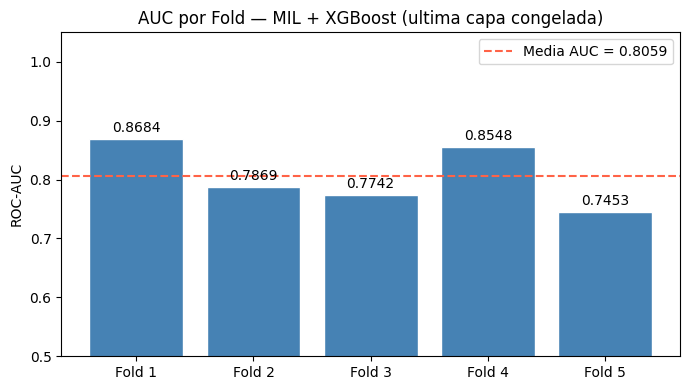

Grafico guardado.


In [ ]:
import pandas as pd

# Construir tabla de resultados
df_cv = pd.DataFrame(resultados_cv)
df_cv = df_cv.set_index("fold")

# Agregar fila de media y std
df_cv.loc["mean"] = df_cv.mean()
df_cv.loc["std"]  = df_cv[df_cv.index != "mean"].std()

print("\n" + "="*65)
print("RESULTADOS CROSS-VALIDATION — MIL + XGBoost (ultima capa)")
print("="*65)
print(df_cv.to_string(float_format="{:.4f}".format))

# Guardar CSV
ruta_cv_csv = f"{RUTA_OUTPUTS}/cv_resultados_xgboost.csv"
df_cv.to_csv(ruta_cv_csv)
print(f"\nResultados CV guardados en: {ruta_cv_csv}")

# Grafico de barras AUC por fold
folds_num = [r["fold"] for r in resultados_cv]
aucs      = [r["auc"]  for r in resultados_cv]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([f"Fold {f}" for f in folds_num], aucs,
              color="steelblue", edgecolor="white")
ax.axhline(sum(aucs)/len(aucs), color="tomato", linestyle="--",
           label=f"Media AUC = {sum(aucs)/len(aucs):.4f}")
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel("ROC-AUC")
ax.set_title("AUC por Fold — MIL + XGBoost (ultima capa congelada)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{RUTA_OUTPUTS}/cv_auc_por_fold_xgboost.png", dpi=120)
plt.show()
print("Grafico guardado.")


### Resultados Consolidados de los 5 Folds

In [ ]:
import pandas as pd

df_all_folds = pd.DataFrame(resultados_cv)
display(df_all_folds)

,fold,auc,f1_S,f1_R,rec_S,rec_R,prec_S,prec_R
0,1,0.868447,0.848485,0.718310,0.877285,0.676991,0.821516,0.765000
1,2,0.786930,0.832794,0.000000,1.000000,0.000000,0.713494,0.000000
2,3,0.774153,0.833333,0.543860,0.863787,0.496000,0.804954,0.601942
3,4,0.854848,0.791523,0.659176,0.895078,0.554331,0.709446,0.812933
4,5,0.745300,0.728559,0.000000,1.000000,0.000000,0.573018,0.000000


## Artefactos para Analisis Estadistico Final (OOF Pooled)

Genera los CSV necesarios para ROC pooled, DeLong CI, McNemar, Clopper-Pearson VME CI
y comparacion contra la regla basada en carbapenemasas. No reentrena modelos ni
realiza el analisis estadistico — solo prepara los datos de entrada.

In [ ]:
import os
import numpy as np
import pandas as pd

RUTA_STATS = f"{RUTA_BASE}/outputs"
os.makedirs(RUTA_STATS, exist_ok=True)
N_FOLDS = 5


def _reconstruir_genome_ids(fold_idx):
    """Fallback si no existe fold{k}_genome_id.npy: reconstruye el orden de
    genome_id leyendo el CSV de validacion, usando el mismo groupby que crear_bags."""
    ruta_val = f"{RUTA_FOLDS}/val_por_cepa_fold{fold_idx}.csv"
    if not os.path.exists(ruta_val):
        return None
    df = pd.read_csv(ruta_val)
    return df.groupby("genome_id").size().index.to_numpy()


print(f"Carpeta de salida de artefactos: {RUTA_STATS}")

### 1. OOF pooled (fold1..fold5 concatenados)

In [ ]:
registros_oof, resumen_carga = [], []

for fold_idx in range(1, N_FOLDS + 1):
    ruta_score = f"{RUTA_OUTPUTS}/fold{fold_idx}_y_score_xgb.npy"
    ruta_true  = f"{RUTA_OUTPUTS}/fold{fold_idx}_y_true.npy"

    if not (os.path.exists(ruta_score) and os.path.exists(ruta_true)):
        print(f"[AVISO] Fold {fold_idx}: faltan y_score_xgb.npy / y_true.npy, se omite este fold.")
        continue

    y_score = np.load(ruta_score)
    y_true  = np.load(ruta_true)

    ruta_gid = f"{RUTA_OUTPUTS}/fold{fold_idx}_genome_id.npy"
    if os.path.exists(ruta_gid):
        genome_ids = np.load(ruta_gid, allow_pickle=True)
    else:
        genome_ids = _reconstruir_genome_ids(fold_idx)
        if genome_ids is None or len(genome_ids) != len(y_true):
            print(f"[AVISO] Fold {fold_idx}: genome_id no disponible o desalineado, se deja vacio.")
            genome_ids = [None] * len(y_true)

    ruta_mil = f"{RUTA_OUTPUTS}/fold{fold_idx}_y_score_mil.npy"
    y_score_mil = np.load(ruta_mil) if os.path.exists(ruta_mil) else np.full(len(y_true), np.nan)

    registros_oof.append(pd.DataFrame({
        "genome_id"   : genome_ids,
        "y_true"      : y_true,
        "y_score"     : y_score,
        "y_score_mil" : y_score_mil,
        "fold"        : fold_idx,
    }))
    resumen_carga.append((fold_idx, len(y_true)))

if registros_oof:
    oof_pooled = pd.concat(registros_oof, ignore_index=True)
    ruta_oof_csv = f"{RUTA_STATS}/oof_predictions_pooled.csv"
    oof_pooled.to_csv(ruta_oof_csv, index=False)
    print(f"OOF pooled: {len(oof_pooled)} aislados de {len(registros_oof)}/{N_FOLDS} folds -> {ruta_oof_csv}")
else:
    oof_pooled = pd.DataFrame(columns=["genome_id", "y_true", "y_score", "y_score_mil", "fold"])
    ruta_oof_csv = f"{RUTA_STATS}/oof_predictions_pooled.csv"
    print("[AVISO] No se encontro ningun fold valido. oof_predictions_pooled.csv no generado.")

### 2. Columna `has_carbapenemase` por genome_id

Se deriva de la columna `Drug Class` de los CSV por-cepa (train/val de cada fold),
buscando genes asociados a carbapenemasas conocidas. Si `Drug Class` no esta
disponible, la columna queda vacia y lista para completarse mas adelante.

In [ ]:
# ── 2. Cargar has_carbapenemase desde Auditoria_Final_Armonizada.xlsx ──
import os
import pandas as pd
import numpy as np

# Intentar cargar desde múltiples rutas posibles
rutas_auditoria = [
    f"{RUTA_BASE}/Auditoria_Final_Armonizada.xlsx",
    f"{RUTA_BASE}/assamble/Auditoria_Final_Armonizada.xlsx",
    "../data/Auditoria_Final_Armonizada.xlsx",
    "../data/Auditoria_Final_Armonizada.xlsx"
]

df_audit = None
for r in rutas_auditoria:
    if os.path.exists(r):
        df_audit = pd.read_excel(r)
        print(f"Loaded Auditoria from: {r}")
        break

if df_audit is not None:
    mapa_carb = df_audit.set_index("genome_id")["Carbapenemase"].to_dict()
    # Si hay algún NaN en la tabla, lo tratamos como 0 (ausencia de carbapenemasa)
    mapa_carb = {k: int(v) if not pd.isna(v) else 0 for k, v in mapa_carb.items()}
else:
    # Fallback descriptivo si no se encuentra
    print("[AVISO] Auditoria_Final_Armonizada.xlsx no encontrada en Google Drive.")
    print("Se intentará derivar desde la columna 'Drug Class' como fallback...")
    mapa_carb = {}
    CARBAPENEMASE_KEYWORDS = ["carbapenem", "OXA", "KPC", "NDM", "VIM", "IMP", "GES"]
    patron = "|".join(CARBAPENEMASE_KEYWORDS)
    for fold_idx in range(1, N_FOLDS + 1):
        for split in ("train", "val"):
            ruta = f"{RUTA_FOLDS}/{split}_por_cepa_fold{fold_idx}.csv"
            if not os.path.exists(ruta):
                continue
            df = pd.read_csv(ruta)
            if "Drug Class" in df.columns:
                es_carb = df["Drug Class"].str.contains(patron, case=False, na=False)
                for gid, tiene in df.assign(_carb=es_carb).groupby("genome_id")["_carb"].any().items():
                    mapa_carb[gid] = mapa_carb.get(gid, False) or bool(tiene)

if mapa_carb and not oof_pooled.empty:
    oof_pooled["has_carbapenemase"] = oof_pooled["genome_id"].map(mapa_carb)
    # Rellenar con 0 si no se encontró en el mapa (por si acaso)
    oof_pooled["has_carbapenemase"] = oof_pooled["has_carbapenemase"].fillna(0).astype(int)
    n_pos = (oof_pooled["has_carbapenemase"] == 1).sum()
    print(f"has_carbapenemase asignado: {n_pos} positivas, {len(oof_pooled) - n_pos} negativas.")
else:
    oof_pooled["has_carbapenemase"] = np.nan
    print("[AVISO] No se pudo derivar has_carbapenemase.")

oof_pooled.to_csv(ruta_oof_csv, index=False)


### 3. `random_split_predictions.csv`

Predicciones del modelo entrenado con split aleatorio (no ST-blocked), usadas para
comparar intervalos de confianza frente al CV por cepa. Ajusta `RUTA_RANDOM_SPLIT`
y los nombres de archivo si difieren de los usados aqui.

In [ ]:
import os
import numpy as np
import pandas as pd

# Buscar en múltiples ubicaciones y nombres posibles
candidatos_score = [
    f"{RUTA_BASE}/random_split/random_split_y_score_xgb.npy",
    f"{RUTA_BASE}/roc_y_score_mil_v53.npy",
    f"{RUTA_BASE}/random_split_y_score_xgb.npy"
]
candidatos_true = [
    f"{RUTA_BASE}/random_split/random_split_y_true.npy",
    f"{RUTA_BASE}/roc_y_true.npy",
    f"{RUTA_BASE}/random_split_y_true.npy"
]
candidatos_gid = [
    f"{RUTA_BASE}/random_split/random_split_genome_id.npy",
    f"{RUTA_BASE}/roc_y_genome_id.npy",
    f"{RUTA_BASE}/random_split_genome_id.npy"
]

ruta_score_rs = next((p for p in candidatos_score if os.path.exists(p)), None)
ruta_true_rs = next((p for p in candidatos_true if os.path.exists(p)), None)
ruta_gid_rs = next((p for p in candidatos_gid if os.path.exists(p)), None)

if ruta_score_rs and ruta_true_rs:
    print(f"Cargando predicciones de random split de:\n  Score: {ruta_score_rs}\n  True:  {ruta_true_rs}")
    y_score_rs = np.load(ruta_score_rs)
    y_true_rs  = np.load(ruta_true_rs)
    
    if ruta_gid_rs:
        genome_ids_rs = np.load(ruta_gid_rs, allow_pickle=True)
    else:
        # Reconstruir desde val_por_cepa.csv si las longitudes coinciden
        ruta_val_rs = f"{RUTA_FOLDS}/val_por_cepa.csv"
        if os.path.exists(ruta_val_rs):
            df_val_rs = pd.read_csv(ruta_val_rs)
            genome_ids_rs = df_val_rs.groupby("genome_id").size().index.to_numpy()
            if len(genome_ids_rs) != len(y_true_rs):
                print(f"[AVISO] Longitud de val_por_cepa.csv ({len(genome_ids_rs)}) no coincide con predicciones ({len(y_true_rs)})")
                genome_ids_rs = [None] * len(y_true_rs)
        else:
            genome_ids_rs = [None] * len(y_true_rs)

    random_split_predictions = pd.DataFrame({
        "genome_id": genome_ids_rs,
        "y_true"   : y_true_rs,
        "y_score"  : y_score_rs,
    })
    ruta_rs_csv = f"{RUTA_STATS}/random_split_predictions.csv"
    random_split_predictions.to_csv(ruta_rs_csv, index=False)
    print(f"random_split_predictions.csv generado -> {ruta_rs_csv}")
else:
    ruta_rs_csv = None
    random_split_predictions = None
    print(f"[AVISO] No se encontraron predicciones de random split.")
    print("Asegúrate de que roc_y_score_mil_v53.npy y roc_y_true.npy estén en RUTA_BASE o en RUTA_BASE/random_split.")


### Resumen de artefactos generados

In [ ]:
print("=" * 60)
print("RESUMEN — Artefactos para analisis estadistico final")
print("=" * 60)

archivos_esperados = [
    ("oof_predictions_pooled.csv",   os.path.exists(f"{RUTA_STATS}/oof_predictions_pooled.csv")),
    ("random_split_predictions.csv", os.path.exists(f"{RUTA_STATS}/random_split_predictions.csv")),
]
for nombre, existe in archivos_esperados:
    print(f"  [{'OK' if existe else 'PENDIENTE'}] {nombre}")

print(f"\nFolds incluidos en OOF pooled : {[f for f, _ in resumen_carga]}")
print(f"Aislados totales en OOF pooled: {len(oof_pooled)}")
print(f"y_score_mil disponible        : {oof_pooled['y_score_mil'].notna().any() if not oof_pooled.empty else False}")
print(f"has_carbapenemase disponible  : {oof_pooled['has_carbapenemase'].notna().any() if not oof_pooled.empty else False}")
print(f"Carpeta de salida             : {RUTA_STATS}")